# Asteroid Mass, Density, and Size Distributions

This notebook explores the physical properties of asteroids using the SBN Archive
asteroid masses dataset. We visualize distributions of:

1. **Mass** (log-scale histogram)
2. **Bulk density** (linear histogram)
3. **Equivalent radius** (log-scale histogram)
4. **Mass vs. size** (scatter plot with density-based reference line)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots  # noqa: F401

from astrojax.datasets import load_asteroid_masses

plt.style.use(["science", "ieee"])

## Load Dataset

The SBN Archive compilation contains mass, density, and tri-axial shape data
for ~248 asteroids. Not all fields are available for every asteroid.

In [9]:
df = load_asteroid_masses()

print(f"Total records: {df.shape[0]}")
print("\nNon-null counts per column:")
for col in df.columns:
    n_valid = df[col].drop_nulls().len()
    print(f"  {col:<20} {n_valid:>5}")

Total records: 248

Non-null counts per column:
  ast_number             248
  ast_name               248
  prov_desig             248
  satellite_name         248
  mass_sol               248
  mass_sol_unc           248
  mass_kg                248
  mass_kg_unc            248
  bulk_density           248
  bulk_density_unc       248
  axis_a                 248
  axis_b                 248
  axis_c                 248
  equiv_radius_unc       248
  mass_ref               248


## Mass Distribution

Asteroid masses in the `mass_kg` column are in kg.
The range spans several orders of magnitude, so a $\log_{10}$ histogram
is appropriate.

/tmp/ipykernel_2080800/1016089810.py:4: RuntimeWarning: invalid value encountered in log10
  log_mass = np.log10(mass_kg)


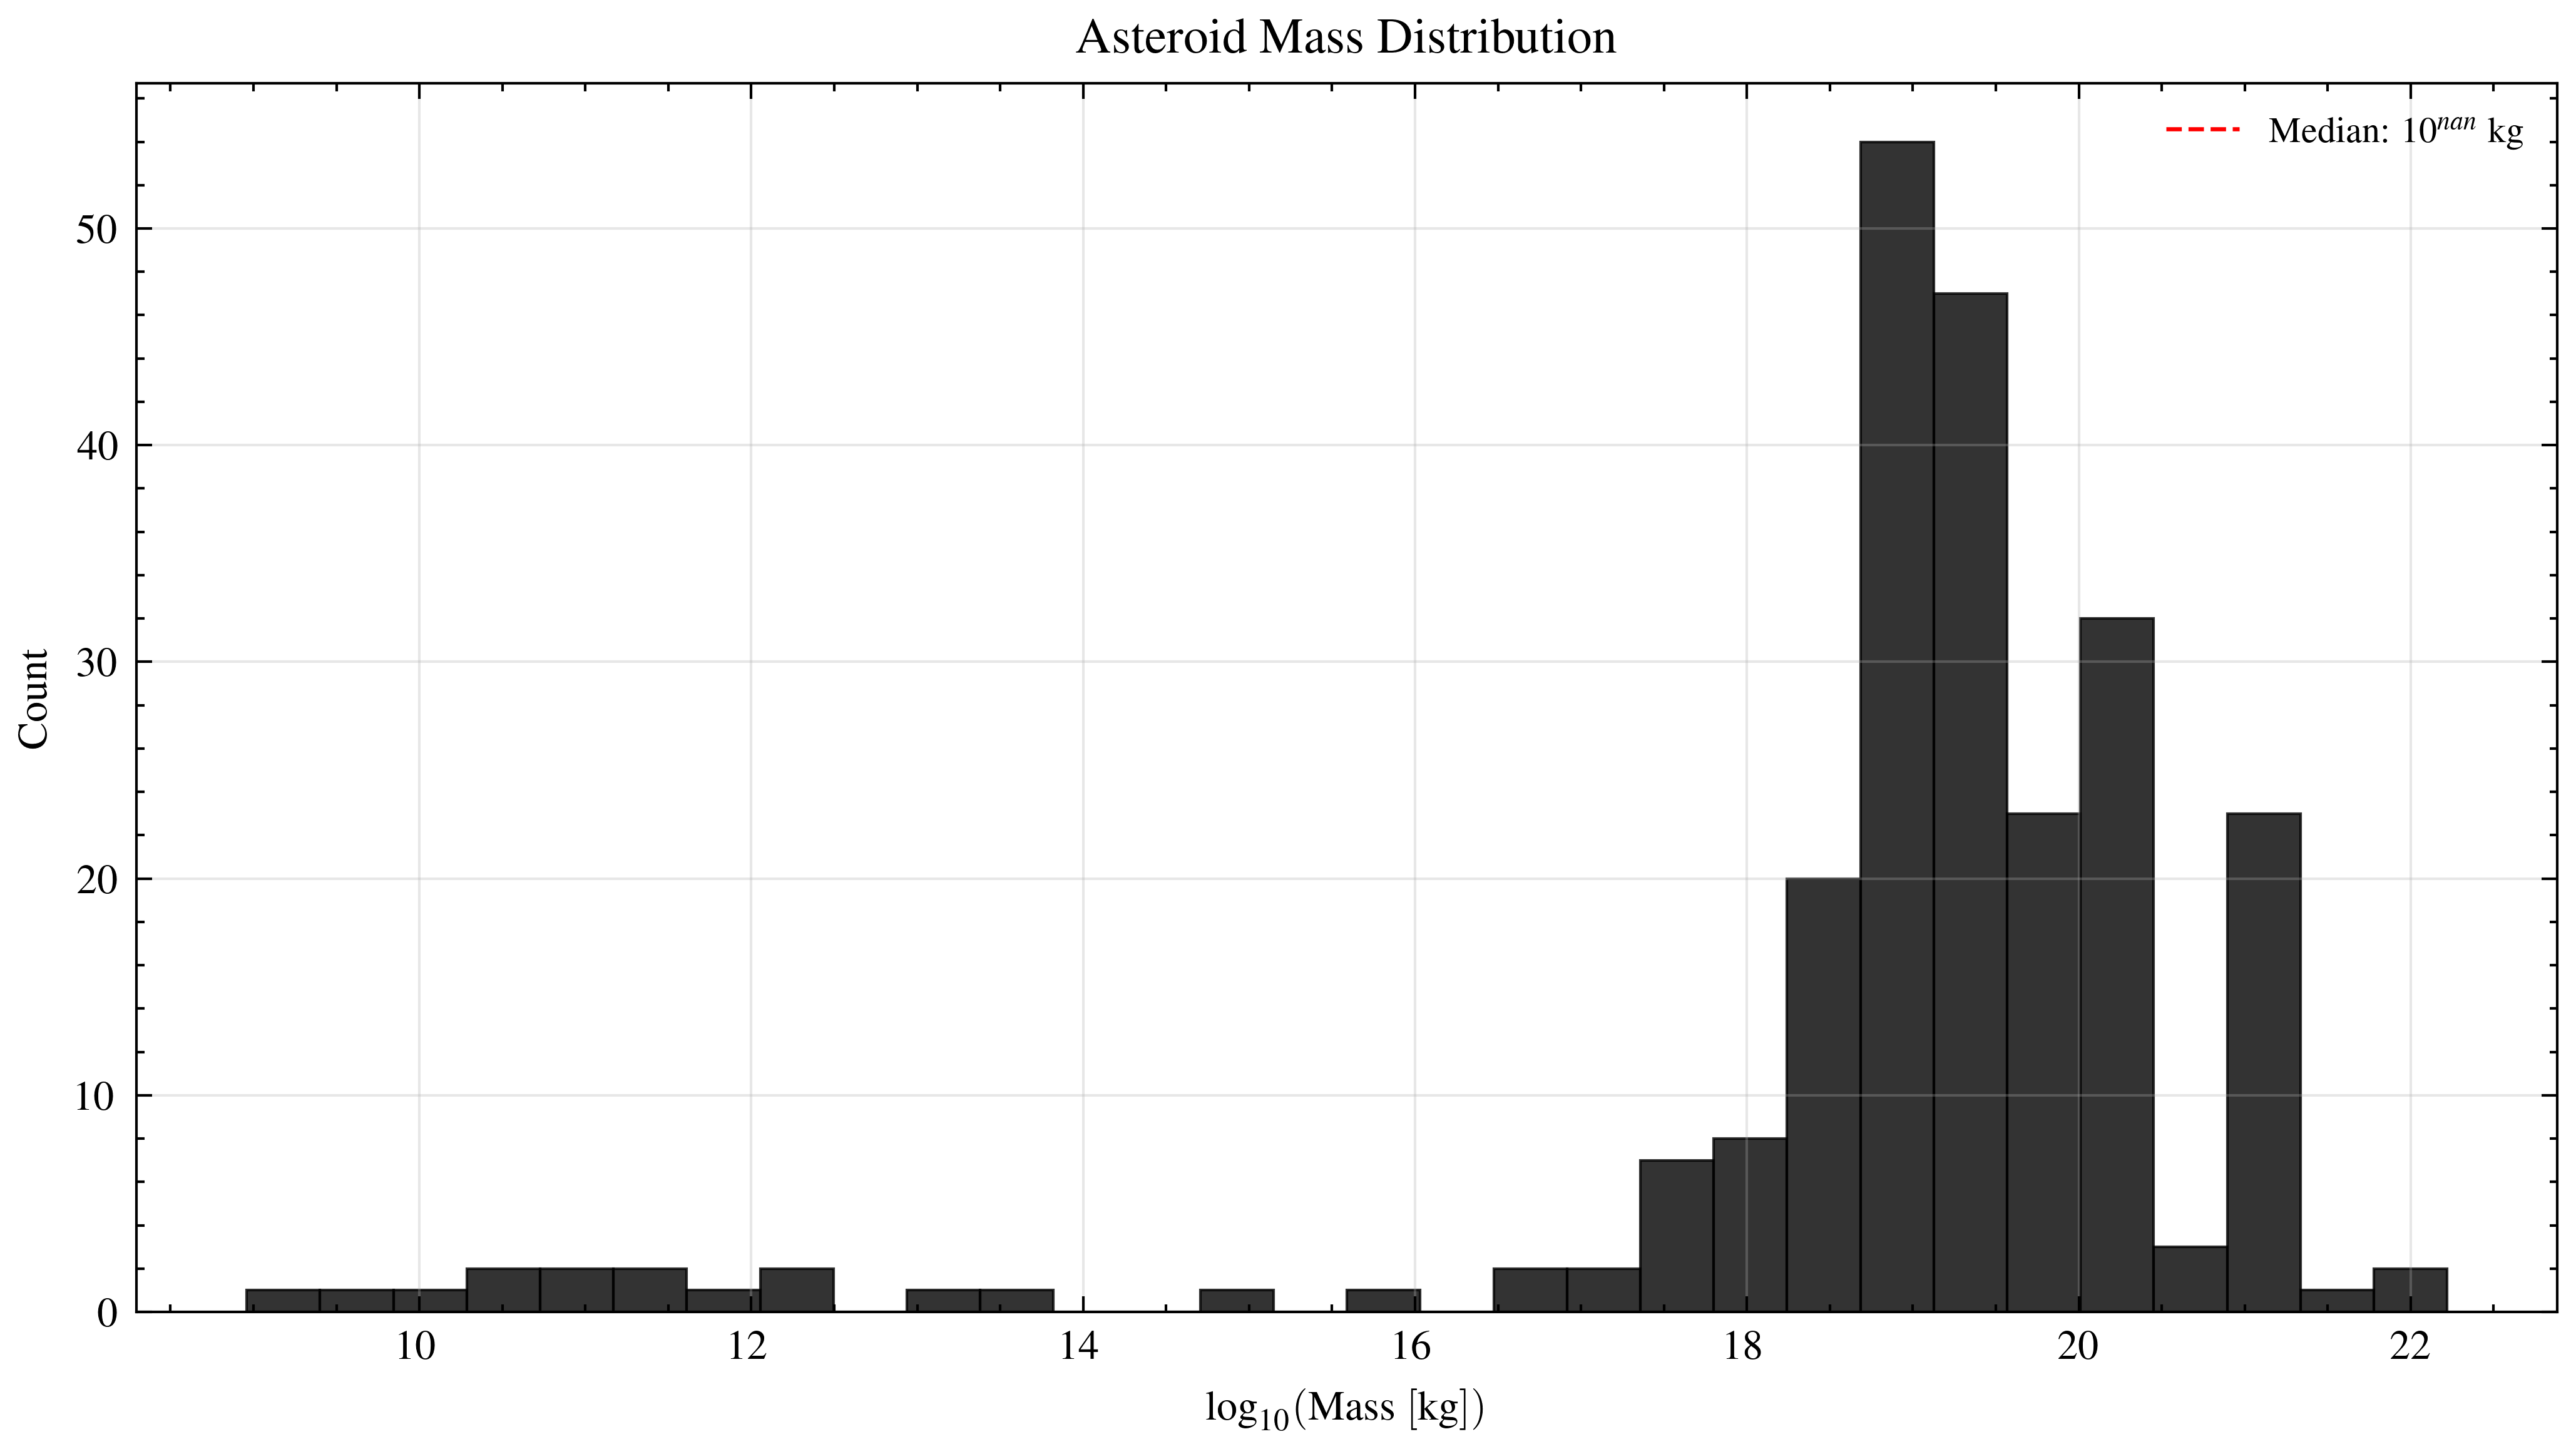

Asteroids with mass data: 248
Mass range: -9.90e-100 to 1.66e+22 kg


In [10]:
# Filter to asteroids with known mass
df_mass = df.filter(pl.col("mass_kg").is_not_null())
mass_kg = df_mass["mass_kg"].to_numpy()
log_mass = np.log10(mass_kg)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_mass, bins=30, edgecolor="k", linewidth=0.5, alpha=0.8)
median_log = np.median(log_mass)
ax.axvline(
    median_log,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: $10^{{{median_log:.1f}}}$ kg",
)
ax.set_xlabel(r"$\log_{10}(\mathrm{Mass\ [kg]})$")
ax.set_ylabel("Count")
ax.set_title("Asteroid Mass Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with mass data: {len(mass_kg)}")
print(f"Mass range: {mass_kg.min():.2e} to {mass_kg.max():.2e} kg")

## Bulk Density Distribution

Bulk density in the dataset is in g/cm$^3$; we convert to kg/m$^3$ for
plotting.  Typical asteroid densities range from ~1000 kg/m$^3$
(ice-rich/porous C-types) to ~5000+ kg/m$^3$ (metallic M-types).

In [ ]:
df_density = df.filter(pl.col("bulk_density").is_not_null())
density = df_density["bulk_density"].to_numpy() * 1000.0  # g/cm^3 -> kg/m^3

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(density, bins=25, edgecolor="k", linewidth=0.5, alpha=0.8)
median_rho = np.median(density)
ax.axvline(
    median_rho,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {median_rho:.0f} kg/m$^3$",
)
ax.set_xlabel(r"Bulk Density [kg/m$^3$]")
ax.set_ylabel("Count")
ax.set_title("Asteroid Bulk Density Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with density data: {len(density)}")
print(f"Density range: {density.min():.0f} to {density.max():.0f} kg/m^3")

## Size Distribution

Tri-axial ellipsoid diameters ($a$, $b$, $c$) are given in km. We compute
the equivalent spherical radius as $R_{\mathrm{eq}} = \frac{1}{2}(a \cdot b \cdot c)^{1/3}$.

/tmp/ipykernel_2080800/873966840.py:11: RuntimeWarning: invalid value encountered in power
  R_eq = (a * b * c) ** (1.0 / 3.0) / 2.0


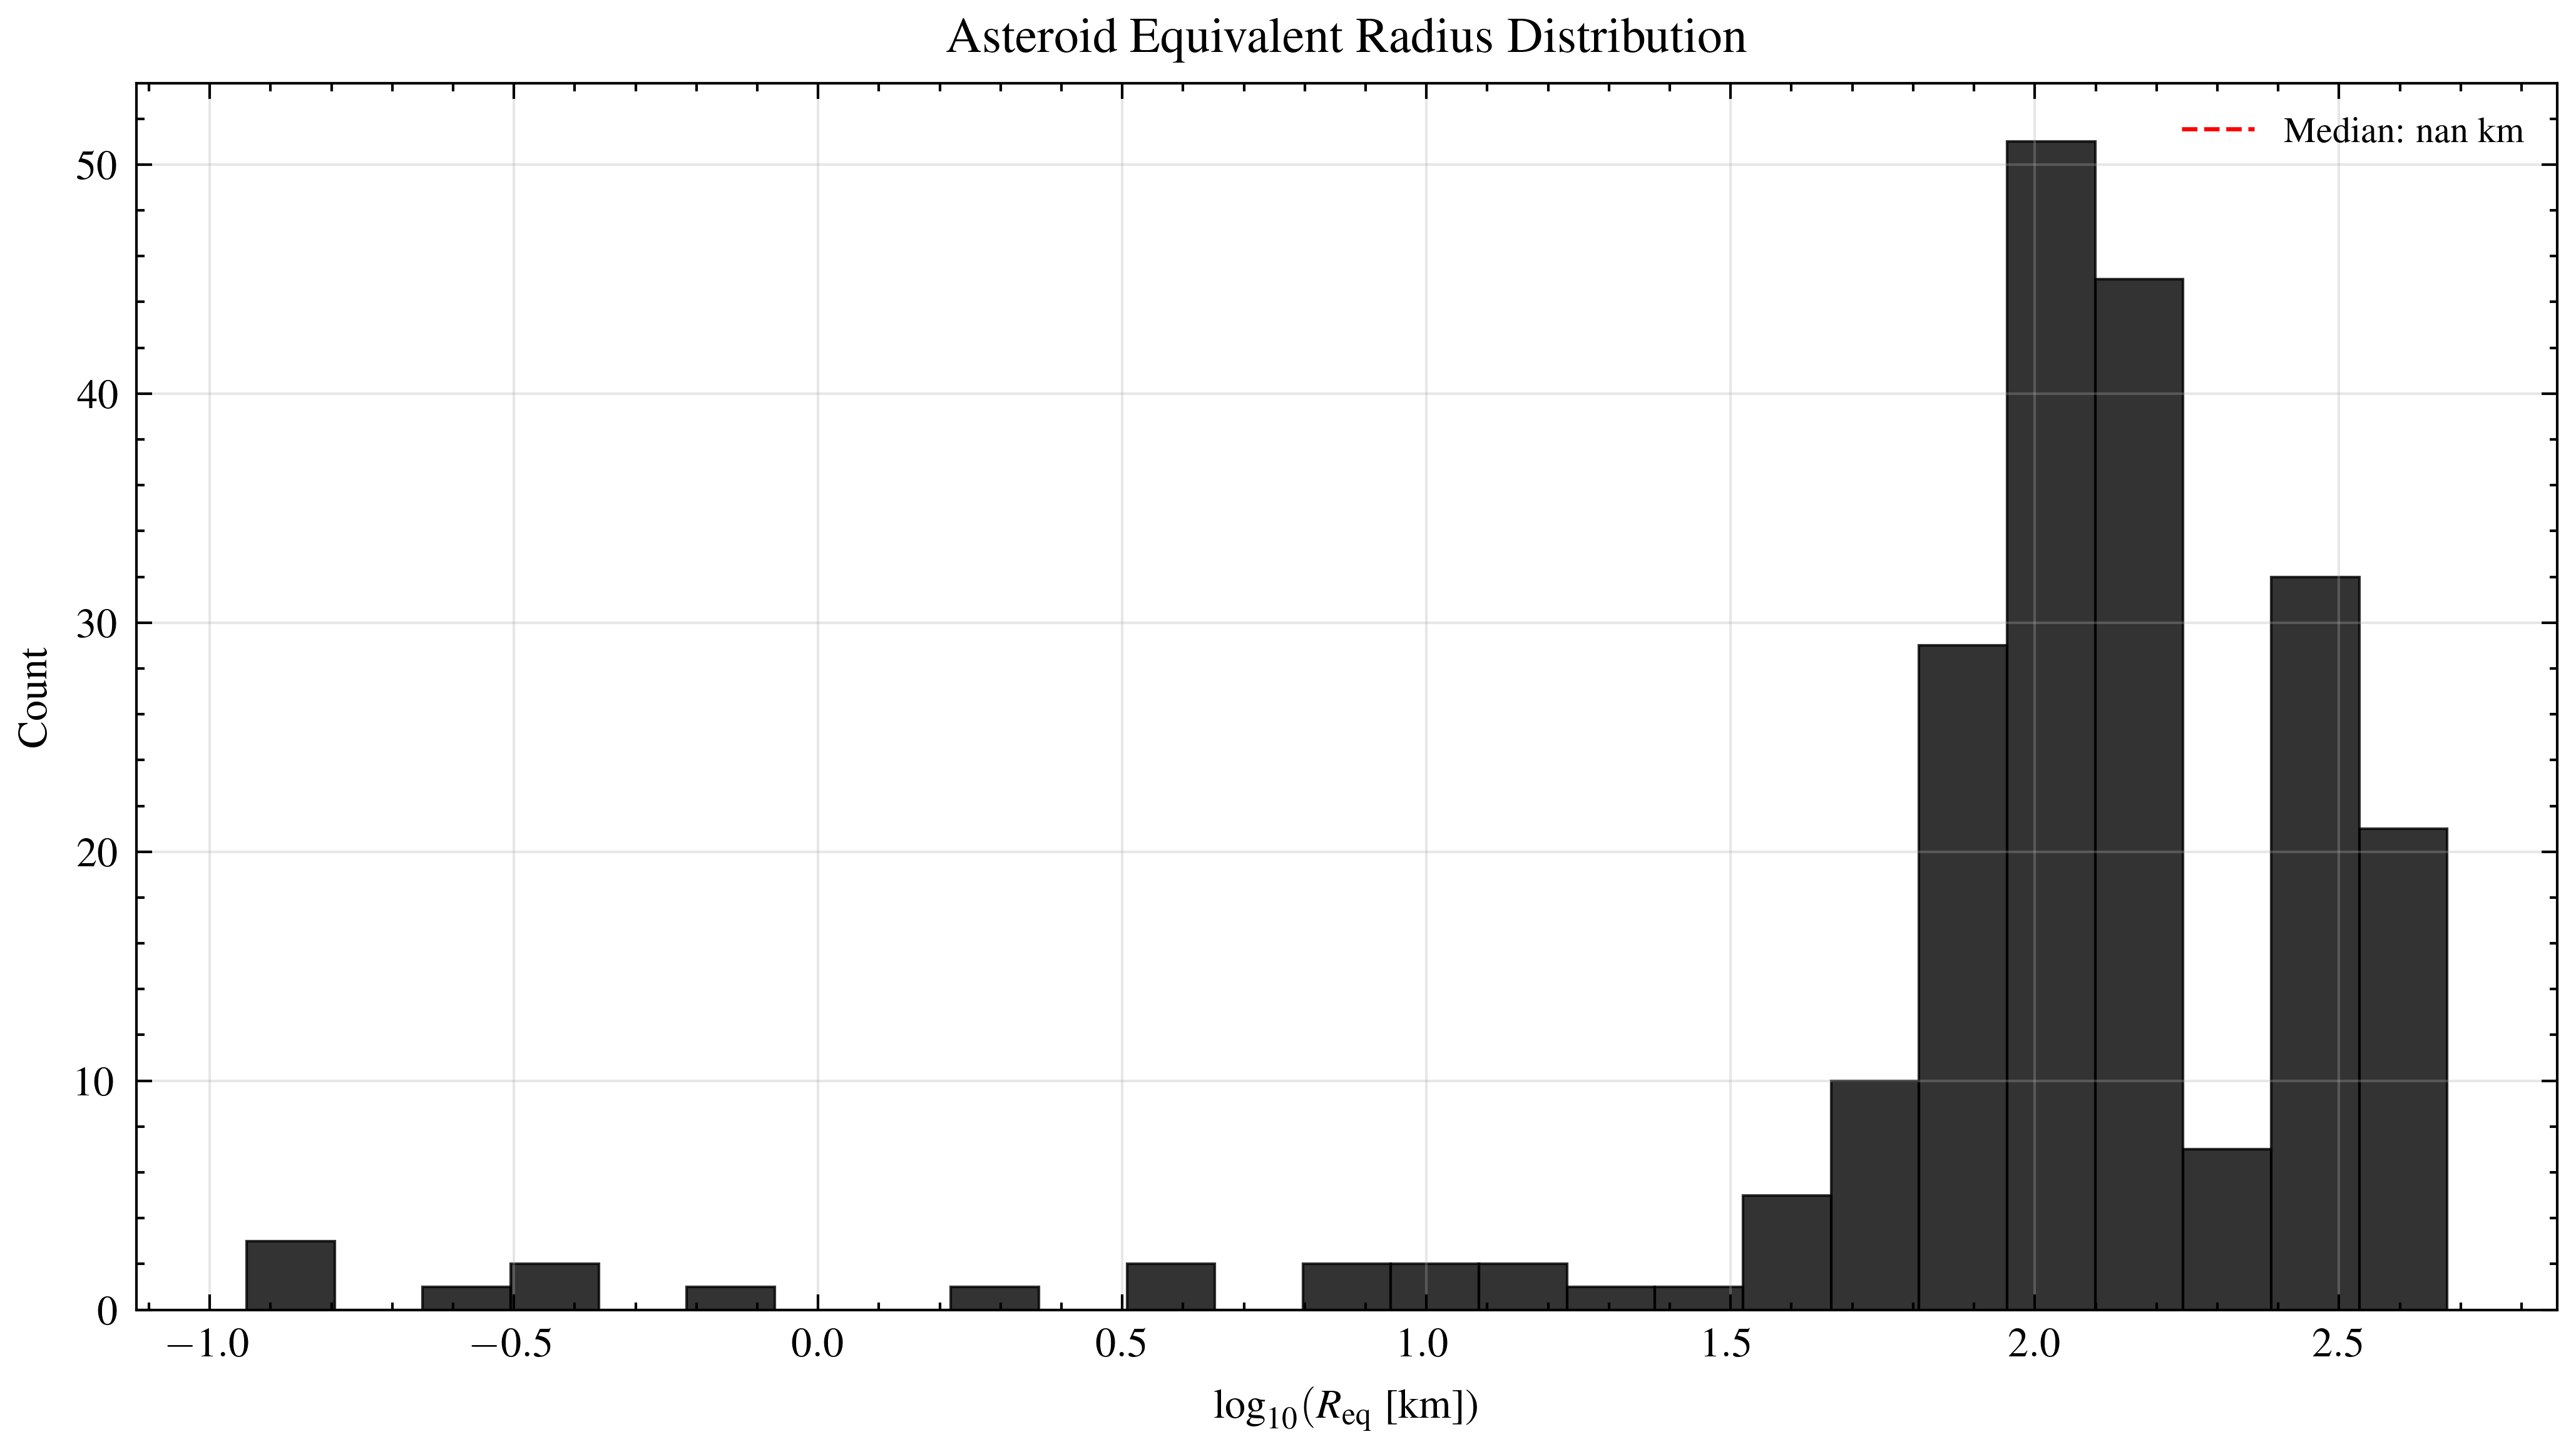

Asteroids with shape data: 248
Radius range: nan to nan km


In [12]:
df_shape = df.filter(
    pl.col("axis_a").is_not_null() & pl.col("axis_b").is_not_null() & pl.col("axis_c").is_not_null()
)
a = df_shape["axis_a"].to_numpy()
b = df_shape["axis_b"].to_numpy()
c = df_shape["axis_c"].to_numpy()

# Equivalent spherical radius [km] (axes are diameters, divide by 2)
R_eq = (a * b * c) ** (1.0 / 3.0) / 2.0
log_R = np.log10(R_eq)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_R, bins=25, edgecolor="k", linewidth=0.5, alpha=0.8)
median_log_R = np.median(log_R)
ax.axvline(
    median_log_R,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {10**median_log_R:.1f} km",
)
ax.set_xlabel(r"$\log_{10}(R_{\mathrm{eq}}$ [km])")
ax.set_ylabel("Count")
ax.set_title("Asteroid Equivalent Radius Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with shape data: {len(R_eq)}")
print(f"Radius range: {R_eq.min():.1f} to {R_eq.max():.1f} km")

## Mass vs. Size

Scatter plot of mass versus equivalent radius, colored by bulk density
where available. A reference line shows the expected relationship
$M = \frac{4}{3}\pi \rho R^3$ for $\rho = 2500$ kg/m$^3$ (typical S-type asteroid).

In [ ]:
# Filter to asteroids with both mass and all three shape axes
df_both = df.filter(
    pl.col("mass_kg").is_not_null()
    & pl.col("axis_a").is_not_null()
    & pl.col("axis_b").is_not_null()
    & pl.col("axis_c").is_not_null()
)

mass_both = df_both["mass_kg"].to_numpy()  # already in kg
a_both = df_both["axis_a"].to_numpy()
b_both = df_both["axis_b"].to_numpy()
c_both = df_both["axis_c"].to_numpy()
R_both = (a_both * b_both * c_both) ** (1.0 / 3.0) / 2.0  # radius in km (axes are diameters)

# Density for coloring in kg/m^3 (dataset is g/cm^3)
density_both = df_both["bulk_density"].to_numpy().astype(float) * 1000.0
has_density = ~np.isnan(density_both)

fig, ax = plt.subplots(figsize=(7, 5))

# Points without density data
if np.any(~has_density):
    ax.scatter(
        R_both[~has_density],
        mass_both[~has_density],
        s=15,
        c="grey",
        alpha=0.5,
        edgecolors="k",
        linewidths=0.3,
        label="No density data",
        zorder=2,
    )

# Points with density data (colored)
if np.any(has_density):
    sc = ax.scatter(
        R_both[has_density],
        mass_both[has_density],
        s=25,
        c=density_both[has_density],
        cmap="viridis",
        edgecolors="k",
        linewidths=0.3,
        zorder=3,
        vmin=1000.0,
        vmax=5000.0,
    )
    fig.colorbar(sc, ax=ax, label=r"Bulk density [kg/m$^3$]", shrink=0.8)

# Reference line: M = (4/3) pi rho R^3 for rho = 2500 kg/m^3
R_ref = np.logspace(np.log10(1), np.log10(600), 100)  # km
rho_ref = 2500.0  # kg/m^3
R_ref_m = R_ref * 1e3  # convert km to m
M_ref = (4.0 / 3.0) * np.pi * rho_ref * R_ref_m**3  # kg
ax.plot(R_ref, M_ref, "k--", linewidth=0.8, alpha=0.6, label=r"$\rho = 2500$ kg/m$^3$")

# Annotate notable asteroids
notable = {"Ceres": 1, "Vesta": 4, "Pallas": 2, "Hygiea": 10, "Psyche": 16}
for name, number in notable.items():
    mask = df_both["ast_number"].to_numpy() == number
    if np.any(mask):
        idx = np.argmax(mask)
        ax.annotate(
            name,
            (R_both[idx], mass_both[idx]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Equivalent Radius [km]")
ax.set_ylabel("Mass [kg]")
ax.set_title("Asteroid Mass vs. Size")
ax.legend(fontsize=6, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with both mass and shape: {len(R_both)}")

## Summary Statistics

In [14]:
print("Dataset summary:")
print(f"  Total records:              {df.shape[0]}")
print(f"  With mass:                  {df.filter(pl.col('mass_kg').is_not_null()).shape[0]}")
print(f"  With bulk density:          {df.filter(pl.col('bulk_density').is_not_null()).shape[0]}")
print(f"  With shape (all 3 axes):    {df_shape.shape[0]}")
print(f"  With mass + shape:          {df_both.shape[0]}")
print()

# Top 5 most massive
top5 = df.sort("mass_kg", descending=True, nulls_last=True).head(5)
print("Top 5 most massive asteroids:")
print(top5.select(["ast_number", "ast_name", "mass_kg", "bulk_density"]))

Dataset summary:
  Total records:              248
  With mass:                  248
  With bulk density:          248
  With shape (all 3 axes):    248
  With mass + shape:          248

Top 5 most massive asteroids:
shape: (5, 4)
┌────────────┬──────────┬───────────┬──────────────┐
│ ast_number ┆ ast_name ┆ mass_kg   ┆ bulk_density │
│ ---        ┆ ---      ┆ ---       ┆ ---          │
│ i64        ┆ str      ┆ f64       ┆ f64          │
╞════════════╪══════════╪═══════════╪══════════════╡
│ 136199     ┆ Eris     ┆ 1.6600e22 ┆ 2.26         │
│ 134340     ┆ Pluto    ┆ 1.3000e22 ┆ 2.03         │
│ 136108     ┆ Haumea   ┆ 4.0000e21 ┆ -0.99        │
│ 50000      ┆ Quaoar   ┆ 1.6000e21 ┆ 4.2          │
│ 0          ┆ -        ┆ 1.5200e21 ┆ 1.63         │
└────────────┴──────────┴───────────┴──────────────┘
